In [1]:
import piplite
await piplite.install(['numpy','pandas'])
await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

Matplotlib is building the font cache; this may take a moment.


In [15]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [16]:
boston_df=pd.read_csv(boston_url)

In [17]:
boston_df

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
502,502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
503,503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9
504,504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48,22.0


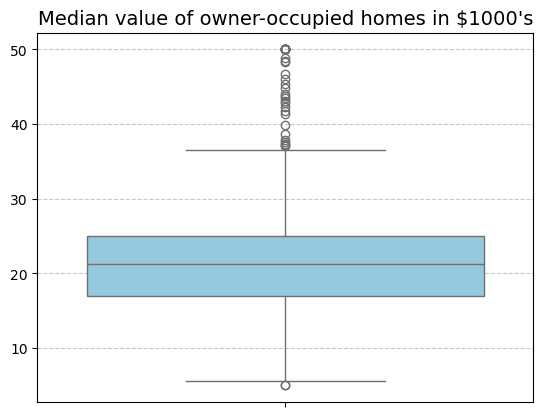

In [8]:
# For the "Median value of owner-occupied homes" provide a boxplot
sns.boxplot(boston_df["MEDV"], color='skyblue')
plt.title("Median value of owner-occupied homes in $1000's", fontsize=14)
plt.ylabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

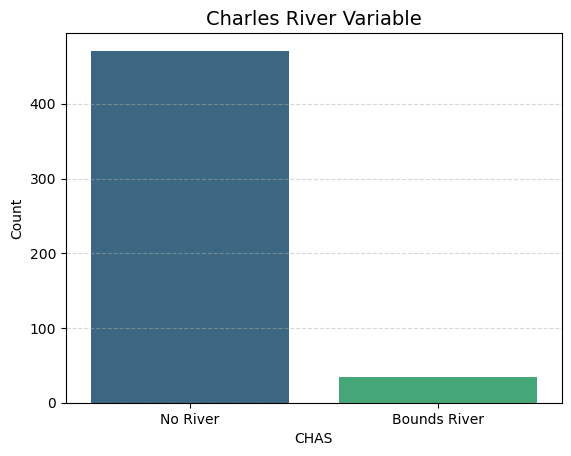

In [24]:
chas_counts = boston_df['CHAS'].value_counts().reset_index()
chas_counts.columns = ['CHAS', 'Count']

sns.barplot(data=chas_counts, x='CHAS', y='Count', hue='CHAS', palette='viridis', legend=False)

plt.title('Charles River Variable', fontsize=14)
plt.xlabel('CHAS')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No River', 'Bounds River'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

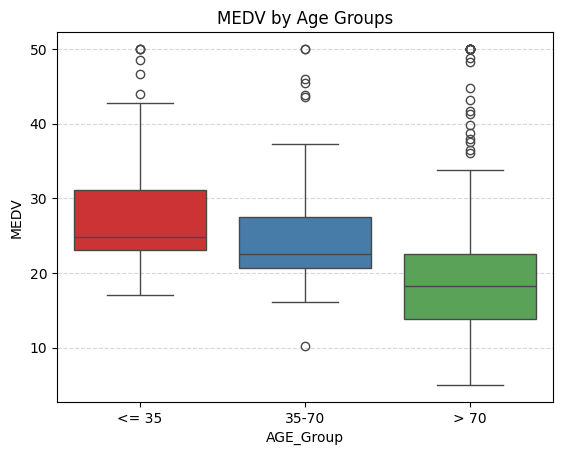

In [19]:
bins = [0, 35, 70, boston_df['AGE'].max()]
labels = ['<= 35', '35-70', '> 70']
boston_df['AGE_Group'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels)

sns.boxplot(data=boston_df, x='AGE_Group', y='MEDV', hue='AGE_Group', palette='Set1')
plt.title("MEDV by Age Groups")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

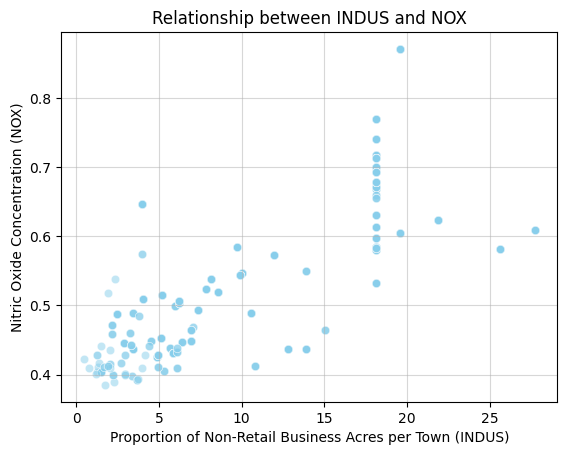

In [25]:
sns.scatterplot(x=boston_df['INDUS'], y=boston_df['NOX'], color='skyblue', alpha=0.5)

plt.title('Relationship between INDUS and NOX')
plt.xlabel('Proportion of Non-Retail Business Acres per Town (INDUS)')
plt.ylabel('Nitric Oxide Concentration (NOX)')
plt.grid(alpha=0.5)
plt.show()

In [26]:
#Industrial zones contribute to air pollution

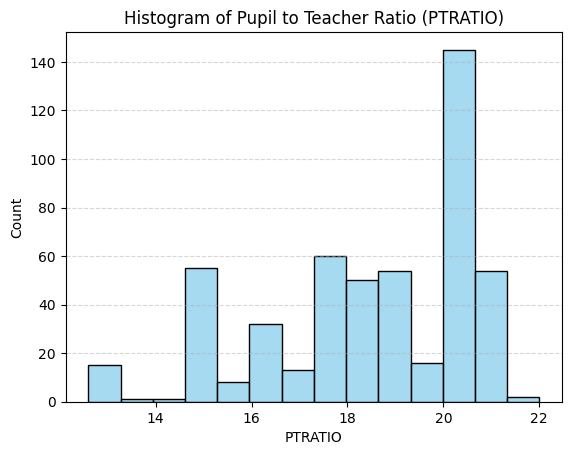

In [27]:
sns.histplot(boston_df['PTRATIO'], color='skyblue')
plt.title("Histogram of Pupil to Teacher Ratio (PTRATIO)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [29]:
# H0: There is no significant difference in the median value of houses bounded by the Charles river.
# H1: There is a significant difference in the median value of houses bounded by the Charles river.

medv_chas_1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
medv_chas_0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

t_stat, p_value = stats.ttest_ind(medv_chas_0, medv_chas_1, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

#Conclusion
alpha = 0.05
if p_value < alpha:
    print("Conclusion: There is a significant difference in the median value of houses bounded by the Charles river.")
else:
    print("Conclusion: There is no significant difference in the median value of houses bounded by the Charles river.")

t-statistic: -3.113291312794837
p-value: 0.0035671700981375174
Conclusion: There is a significant difference in the median value of houses bounded by the Charles river.


In [32]:
#H0: There is no significant difference in MEDV among AGE groups.
#H1: There is a significant difference in MEDV among AGE groups.

bins = [0, 35, 70, boston_df['AGE'].max()]
labels = ['<= 35', '35-70', '> 70']
boston_df['AGE_group'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels)

group1 = boston_df[boston_df['AGE_group'] == '<= 35']['MEDV']
group2 = boston_df[boston_df['AGE_group'] == '35-70']['MEDV']
group3 = boston_df[boston_df['AGE_group'] == '> 70']['MEDV']

f_stat, p_value = stats.f_oneway(group1, group2, group3)

print("ANOVA test")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Conclusion: There is a significant difference in MEDV among AGE groups.")
else:
    print("Conclusion: There is no significant difference in MEDV among AGE groups.")


ANOVA test
F-statistic: 36.40764999196599
P-value: 1.7105011022702984e-15
Conclusion: There is a significant difference in MEDV among AGE groups.


In [34]:
#H0: There is no linear relationship between NOX and INDUS.
#H1: There is a linear relationship between NOX and INDUS.

corr_coef, p_value = stats.pearsonr(boston_df['INDUS'], boston_df['NOX'])

print("Pearson Correlation Test")
print("correlation coefficient:", corr_coef)
print("p-value:", p_value)

if p_value < 0.05:
    print("There is a linear relationship between NOX and INDUS.")
else:
    print("There is no linear relationship between NOX and INDUS.")


Pearson Correlation Test
correlation coefficient: 0.763651446920915
p-value: 7.913361061241112e-98
There is a linear relationship between NOX and INDUS.


In [37]:
#H0: DIS does not have a significant impact on MEDV.
#H1: Conclusion: DIS has a significant impact on MEDV.

x = boston_df[['DIS']]
y = boston_df['MEDV']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

p_value = model.pvalues['DIS']
if p_value < alpha:
    print(f"Conclusion: DIS has a significant impact on MEDV (p_value = {p_value:.10f})")
else:
    print(f"Conclusion: DIS does not have a significant impact on MEDV (p_value = {p_value:.10f})")


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           1.21e-08
Time:                        11:52:57   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0